In [1]:
import numpy as np
import matplotlib.pyplot as plt
import shutil, os
from scipy import integrate, optimize, special

fontsi  = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({
    'font.size':         fontsi,
    'axes.titlesize':    fontsi2,
    'axes.labelsize':    fontsi2 - 1,
    'xtick.labelsize':   fontsi,
    'ytick.labelsize':   fontsi,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'legend.frameon':    False,
    'figure.dpi':        130,
})
os.makedirs('sheet6_output', exist_ok=True)
C_BLUE   = '#1f4e79'
C_ORANGE = '#8c2d19'
C_GREEN  = '#2d6a4f'
C_GRAY   = '#6c757d'
C_RED    = '#c0392b'

# 6.1 Bayesian evidence in the Laplace approximation

Show explicitly how the Bayesian evidence penalises model complexity using the Laplace approximation. Let the evidence for a model with parameter vector $\boldsymbol{\theta} \in \mathbb{R}^d$ be

$$
Z = p(\boldsymbol{x}) = \int \mathcal{L}(\boldsymbol{\theta})\, \pi(\boldsymbol{\theta})\, \mathrm{d}^d\theta.
$$

Assume that the posterior is sharply peaked and can be approximated near its mode $\boldsymbol{\theta}_*$ by a Gaussian obtained from a second-order Taylor expansion of the log posterior (as in the lecture). Let

$$
\boldsymbol{H} = -\left. \nabla_{\theta}\nabla_{\theta} \ln p(\boldsymbol{\theta}\mid \boldsymbol{x}) \right|_{\boldsymbol{\theta}_*},
\qquad
\boldsymbol{C} = \boldsymbol{H}^{-1}.
$$

Assume also that the prior is flat over a parameter-space volume $V_\pi$, so that $\pi(\boldsymbol{\theta}) = 1/V_\pi$ within that volume, and in particular $\pi(\boldsymbol{\theta}_*) = 1/V_\pi$.

**a.** Expand $\ln p(\boldsymbol{\theta}\mid \boldsymbol{x})$ to second order around $\boldsymbol{\theta}_*$, and show that the posterior is approximated by a multivariate Gaussian with covariance matrix $\boldsymbol{C}$.

**b.** Use this Gaussian approximation to evaluate the evidence integral and show that
$$Z \simeq \mathcal{L}(\boldsymbol{\theta}_*) \, \frac{(2\pi)^{d/2} \det(\boldsymbol{C})^{1/2}}{V_\pi}.$$

**c.** Now assume a regular model in the large-sample limit, so that the Hessian scales as $\boldsymbol{H} \propto n$, where $n$ is the number of data points. Show that this implies
$$\det(\boldsymbol{C})^{1/2} \propto n^{-d/2}.$$

**d.** Now prove that, for large $n$,
$$-2 \ln Z \;\to\; -2 \ln \mathcal{L}(\boldsymbol{\theta}_*) + d \ln n + \text{terms independent of } n.$$
Interpret this result as the Bayesian information criterion, and explain why each additional parameter contributes a complexity penalty of $\ln n$.

---

## Solution

### Part a

At the mode $\boldsymbol{\theta}_*$ the gradient of $\ln p(\boldsymbol{\theta}|\boldsymbol{x})$ vanishes by definition. The second-order Taylor expansion therefore reads

$$
\ln p(\boldsymbol{\theta}|\boldsymbol{x})
\approx \ln p(\boldsymbol{\theta}_*|\boldsymbol{x})
  - \tfrac{1}{2}(\boldsymbol{\theta}-\boldsymbol{\theta}_*)^\top
    \boldsymbol{H}\,(\boldsymbol{\theta}-\boldsymbol{\theta}_*).
$$

Exponentiating:

$$
p(\boldsymbol{\theta}|\boldsymbol{x})
\approx p(\boldsymbol{\theta}_*|\boldsymbol{x})
  \exp\!\left(-\tfrac{1}{2}(\boldsymbol{\theta}-\boldsymbol{\theta}_*)^\top
    \boldsymbol{H}\,(\boldsymbol{\theta}-\boldsymbol{\theta}_*)\right),
$$

which is proportional to $\mathcal{N}(\boldsymbol{\theta}_*,\boldsymbol{C})$ with $\boldsymbol{C}=\boldsymbol{H}^{-1}$. $\square$

### Part b

The same Taylor expansion applies to the log of the integrand $\mathcal{L}(\boldsymbol{\theta})\pi(\boldsymbol{\theta})$. For a flat prior, $\ln\pi$ contributes no curvature, so the Hessian of $\ln[\mathcal{L}\pi]$ at $\boldsymbol{\theta}_*$ equals the Hessian of $\ln p(\boldsymbol{\theta}|\boldsymbol{x})$, which is $-\boldsymbol{H}$ by definition. Hence:

$$
\mathcal{L}(\boldsymbol{\theta})\,\pi(\boldsymbol{\theta})
\;\approx\;
\mathcal{L}(\boldsymbol{\theta}_*)\,\pi(\boldsymbol{\theta}_*)
\exp\!\left(-\tfrac{1}{2}(\boldsymbol{\theta}-\boldsymbol{\theta}_*)^\top\boldsymbol{H}\,(\boldsymbol{\theta}-\boldsymbol{\theta}_*)\right).
$$

Substituting $\boldsymbol{\delta} = \boldsymbol{\theta} - \boldsymbol{\theta}_*$ and pulling the constant prefactor outside:

$$
Z \approx \mathcal{L}(\boldsymbol{\theta}_*)\,\pi(\boldsymbol{\theta}_*)
\underbrace{\int_{\mathbb{R}^d}
  \exp\!\left(-\tfrac{1}{2}\,\boldsymbol{\delta}^\top\boldsymbol{H}\,\boldsymbol{\delta}\right)
  \mathrm{d}^d\delta}_{I}.
$$

**Evaluating $I$.** Since $\boldsymbol{H}$ is real symmetric positive-definite it admits an eigendecomposition $\boldsymbol{H} = \boldsymbol{O}^\top\boldsymbol{\Lambda}\boldsymbol{O}$, where $\boldsymbol{O}$ is orthogonal and $\boldsymbol{\Lambda}=\mathrm{diag}(\lambda_1,\ldots,\lambda_d)$ with $\lambda_i>0$. Change variables to $\boldsymbol{u}=\boldsymbol{O}\boldsymbol{\delta}$; since $|\det\boldsymbol{O}|=1$ the volume element is unchanged ($\mathrm{d}^d\delta = \mathrm{d}^d u$), and $\boldsymbol{\delta}^\top\boldsymbol{H}\boldsymbol{\delta} = \boldsymbol{u}^\top\boldsymbol{\Lambda}\boldsymbol{u} = \sum_{i=1}^d \lambda_i u_i^2$. The integral therefore factorises:

$$
I = \int_{\mathbb{R}^d} e^{-\frac{1}{2}\sum_i \lambda_i u_i^2}\,\mathrm{d}^d u
  = \prod_{i=1}^{d}\int_{-\infty}^{\infty} e^{-\frac{1}{2}\lambda_i u_i^2}\,\mathrm{d}u_i
  = \prod_{i=1}^{d}\sqrt{\frac{2\pi}{\lambda_i}}
  = (2\pi)^{d/2}\prod_{i=1}^{d}\lambda_i^{-1/2}.
$$

Because $\prod_i \lambda_i = \det\boldsymbol{\Lambda} = \det\boldsymbol{H}$ and $\det(\boldsymbol{C}) = (\det\boldsymbol{H})^{-1}$:

$$
I = (2\pi)^{d/2}(\det\boldsymbol{H})^{-1/2} = (2\pi)^{d/2}\det(\boldsymbol{C})^{1/2}.
$$

Inserting $\pi(\boldsymbol{\theta}_*)=1/V_\pi$:

$$
{Z \simeq \mathcal{L}(\boldsymbol{\theta}_*)\,
  \frac{(2\pi)^{d/2}\det(\boldsymbol{C})^{1/2}}{V_\pi}.} 
$$

### Part c

If $\boldsymbol{H} = n\,\boldsymbol{H}_0$ for a fixed positive-definite matrix $\boldsymbol{H}_0$, then $\boldsymbol{C}=n^{-1}\boldsymbol{H}_0^{-1}$, so

$$
\det(\boldsymbol{C}) = n^{-d}\det(\boldsymbol{H}_0^{-1}),
\qquad
\det(\boldsymbol{C})^{1/2} = \frac{\det(\boldsymbol{H}_0^{-1})^{1/2}}{n^{d/2}} \propto n^{-d/2}. 
$$

### Part d

Taking $-2\ln$ of the result from (b) and inserting $\det(\boldsymbol{C})^{1/2}\propto n^{-d/2}$ from (c):

$$
\ln Z \simeq \ln\mathcal{L}(\boldsymbol{\theta}_*)
  + \tfrac{d}{2}\ln(2\pi)
  + \underbrace{\tfrac{1}{2}\ln\det(\boldsymbol{C})}_{=-\frac{d}{2}\ln n+\mathrm{const}}
  - \ln V_\pi,
$$

so

$$
{-2\ln Z \;\to\; -2\ln\mathcal{L}(\boldsymbol{\theta}_*) + d\ln n
  + \text{terms independent of }n.}
$$

This is the **Bayesian information criterion (BIC)**. The $+\ln n$ penalty per parameter arises because the posterior volume $V_{\mathrm{post}}\propto n^{-d/2}$ shrinks as more data accumulate while the prior volume $V_\pi$ stays fixed. The ratio $V_{\mathrm{post}}/V_\pi \propto n^{-d/2}$ measures the wasted prior space; $-2\ln$ of one factor $n^{-1/2}$ per parameter gives $+\ln n$ per parameter. $\square$

# 6.2 Inversion transformation sampling

We would like to produce a random sample $\{x_i\}$ drawn from the probability distribution function

$$
p(x) = \frac{1}{Z}\, x^2 e^{-x^2/2}, \qquad x \ge 0,
$$

and $p(x)=0$ for $x<0$, where $Z$ is the normalisation constant.

**a.** Show that $p(x)$ is normalised on $[0,\infty)$ by determining the normalisation constant $Z$.

**b.** Compute the cumulative distribution function
$$F(x) = \int_0^x p(t)\,dt.$$
Show that the resulting expression cannot be inverted in closed form to obtain $x = F^{-1}(u)$ analytically.

**c.** Use a numerical root-finding method to generate samples from this distribution with the inverse transform method. In other words, for each uniform random number $u \in [0,1)$, solve $F(x) = u$ numerically for $x$.

**d.** Write a program to generate $N = 10^6$ random numbers distributed according to $p(x)$ using your numerical inversion method and plot a histogram of the generated sample comparing it with the analytic PDF.

---

## Solution

### Part a

Substitute $t = x^2/2$, so $x = \sqrt{2t}$ and $dx = dt/\sqrt{2t}$:

$$
Z = \int_0^\infty x^2 e^{-x^2/2}\,dx
  = \int_0^\infty 2t\,e^{-t}\frac{dt}{\sqrt{2t}}
  = \sqrt{2}\int_0^\infty t^{1/2}e^{-t}\,dt
  = \sqrt{2}\,\Gamma\!\left(\tfrac{3}{2}\right)
  = \sqrt{2}\cdot\frac{\sqrt{\pi}}{2}
  = \sqrt{\frac{\pi}{2}}.
$$

Hence $p(x) = \sqrt{2/\pi}\,x^2 e^{-x^2/2}$ — the **Maxwell speed distribution**. $\square$

### Part b

Integrate by parts with $u = t$, $dv = te^{-t^2/2}\,dt$ (so $v = -e^{-t^2/2}$):

$$
\int_0^x t^2 e^{-t^2/2}\,dt
= \Bigl[-t\,e^{-t^2/2}\Bigr]_0^x + \int_0^x e^{-t^2/2}\,dt
= -x\,e^{-x^2/2} + \sqrt{\frac{\pi}{2}}\,\mathrm{erf}\!\left(\frac{x}{\sqrt{2}}\right).
$$

Dividing by $Z = \sqrt{\pi/2}$:

$$
{F(x) = \mathrm{erf}\!\left(\frac{x}{\sqrt{2}}\right)
      - \sqrt{\frac{2}{\pi}}\,x\,e^{-x^2/2}.}
$$

**Check:** $F'(x)=\sqrt{2/\pi}\,e^{-x^2/2}-\sqrt{2/\pi}(1-x^2)e^{-x^2/2}=\sqrt{2/\pi}\,x^2e^{-x^2/2}=p(x)$ ✓; $F(0)=0$ ✓; $F(\infty)=1$ ✓.

The equation $F(x)=u$ mixes $\mathrm{erf}(x/\sqrt{2})$ with $xe^{-x^2/2}$; no algebraic manipulation can isolate $x$, so $F^{-1}(u)$ has no closed form. $\square$

### Parts c & d — see code cell below

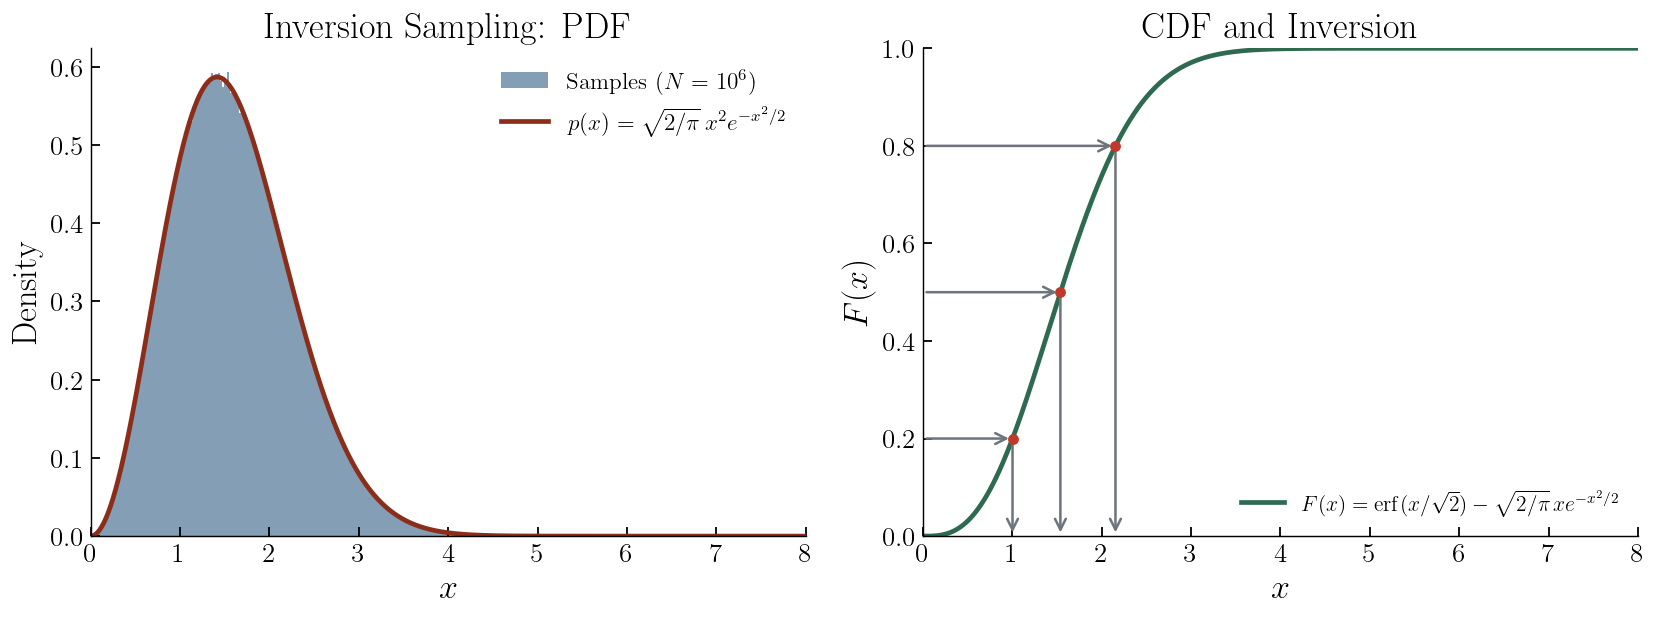

Sample mean: 1.59590  (analytic 2*sqrt(2/pi) = 1.59577)
Sample std:  0.67346  (analytic sqrt(3-8/pi) = 0.67344)


In [2]:
# 6.2 c,d: numerical inversion sampling via lookup table
# Build a dense grid (x, F(x)) and invert by linear interpolation.

Z_norm = np.sqrt(np.pi / 2.0)

def pdf_maxwell(x):
    return x**2 * np.exp(-x**2 / 2.0) / Z_norm

def cdf_maxwell(x):
    return special.erf(x / np.sqrt(2.0)) - np.sqrt(2.0 / np.pi) * x * np.exp(-x**2 / 2.0)

# Verify analytic CDF against quadrature
check_x = 3.0
cdf_quad, _ = integrate.quad(pdf_maxwell, 0, check_x)

# Lookup table: F is monotonically increasing on [0, 15]
x_grid   = np.linspace(0.0, 15.0, 50_000)
cdf_grid = cdf_maxwell(x_grid)

rng = np.random.default_rng(42)
N   = 1_000_000
u   = rng.uniform(0.0, 1.0, N)
x_samples = np.interp(u, cdf_grid, x_grid)   # invert F numerically
#



x_plot = np.linspace(0, 8, 800)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(x_samples, bins=300, density=True,
        color=C_BLUE, alpha=0.55, label=r'Samples ($N=10^6$)')
ax.plot(x_plot, pdf_maxwell(x_plot), lw=2.6, color=C_ORANGE,
        label=r'$p(x)=\sqrt{2/\pi}\,x^2 e^{-x^2/2}$')
ax.set_xlabel(r'$x$')
ax.set_ylabel('Density')
ax.set_xlim(0, 8)
ax.set_title('Inversion Sampling: PDF')
ax.legend(fontsize=fontsi - 2)
ax.tick_params(direction='in', length=5, width=1.0)

ax2 = axes[1]
ax2.plot(x_plot, cdf_maxwell(x_plot), lw=2.6, color=C_GREEN,
         label=r'$F(x)=\mathrm{erf}(x/\sqrt{2})-\sqrt{2/\pi}\,xe^{-x^2/2}$')
for u_ex in [0.2, 0.5, 0.8]:
    x_ex = float(np.interp(u_ex, cdf_grid, x_grid))
    ax2.annotate('', xy=(x_ex, u_ex), xytext=(0.0, u_ex),
                 arrowprops=dict(arrowstyle='->', color=C_GRAY, lw=1.4))
    ax2.annotate('', xy=(x_ex, 0.0), xytext=(x_ex, u_ex),
                 arrowprops=dict(arrowstyle='->', color=C_GRAY, lw=1.4))
    ax2.plot(x_ex, u_ex, 'o', color=C_RED, ms=5, zorder=5)
ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$F(x)$')
ax2.set_xlim(0, 8)
ax2.set_ylim(0, 1)
ax2.set_title('CDF and Inversion')
ax2.legend(fontsize=fontsi - 3, loc='lower right')
ax2.tick_params(direction='in', length=5, width=1.0)

plt.tight_layout()
plt.savefig('sheet6_output/inversion_sampling.pdf', bbox_inches='tight')
plt.show()

print(f'Sample mean: {x_samples.mean():.5f}  (analytic 2*sqrt(2/pi) = {2*np.sqrt(2/np.pi):.5f})')
print(f'Sample std:  {x_samples.std():.5f}  (analytic sqrt(3-8/pi) = {np.sqrt(3-8/np.pi):.5f})')

# 6.3 Rejection sampling

We would like to produce a random sample $\{x_i\}$ drawn from the probability distribution function

$$
p(x) = p_0\bigl((x-2)^4 + \sin^8(x-3)\bigr),
$$

for $0 \le x < 5$, with $p(x) = 0$ outside of this interval.

**a.** Determine $p_0$ such that the function is normalised, i.e.
$$\int_0^5 p(x)\,dx = 1.$$

**b.** Use the rejection method with a uniform parent distribution over the interval $0 \le x < 5$ to create a sample of $N = 10^6$ numbers from this distribution. What is the rejection rate? Plot a histogram of the distribution of your points and compare it with the target distribution function on a common plot with a logarithmic $y$-axis.

**c.** Now consider a function $q(x)$ meant to provide an envelope for $p(x)$. Confirm that the piecewise linear function

$$q(x) = \frac{y_{n+1}-y_n}{x_{n+1}-x_n}(x-x_n) + y_n$$

for $x_n \le x \le x_{n+1}$, with $n \in \{0,1,2,3\}$, fulfills $p(x) \le q(x)$ over the interval $[0,5]$. Use $q(x)$ as an auxiliary function in the rejection method to sample the function $p(x)$ more efficiently. What is the rejection rate now? Verify with another histogram plot that the obtained sample is correct.

---

## Solution

### Part a

Since $p_0$ is a common overall factor, the normalisation condition reads:

$$
p_0 \left[\underbrace{\int_0^5 (x-2)^4\,dx}_{I_1}
+ \underbrace{\int_0^5 \sin^8(x-3)\,dx}_{I_2}\right] = 1.
$$

The first integral is elementary:

$$
I_1 = \left[\frac{(x-2)^5}{5}\right]_0^5
= \frac{3^5 - (-2)^5}{5} = \frac{243+32}{5} = 55.
$$

The second integral $I_2 = \int_{-3}^{2}\sin^8(u)\,du$ (after substituting $u=x-3$) spans a non-integer multiple of $\pi$ and is evaluated numerically (see code). Numerically $I_2 \approx 1.631$, so

$$
{p_0 = \frac{1}{I_1 + I_2} \approx 0.01766.}
$$

Since both $(x-2)^4 \ge 0$ and $\sin^8(x-3) \ge 0$, the PDF is non-negative everywhere. $\square$

### Part b — see first code cell below

### Part c

The nodes from the problem are verified to satisfy $q(x) \ge p(x)$ everywhere on $[0,5]$:

| $n$ | $x_n$ | $y_n$ |
|-----|--------|--------|
| 0   | 0.00   | 0.30   |
| 1   | 0.50   | 0.10   |
| 2   | 2.00   | 0.01   |
| 3   | 3.50   | 0.10   |
| 4   | 5.00   | 1.50   |

The first segment drops steeply to cover the initial peak at $x=0$ where $(x-2)^4=16$ contributes $p(0)\approx 0.28$; the middle segments stay just above the minimum near $x=2$; the final rising segment covers the steep growth of $(x-2)^4$ toward $x=5$, where $p(5)\approx 1.44$. See second code cell below.

I1 = 55.000000  (analytic 55)
I2 = 1.630868
p0 = 0.01765821
Normalisation check: 1.0000000000

p_max = 1.438568 at x = 5.000
Expected acceptance rate (uniform): 13.90%
Observed rejection rate (uniform): 86.12%


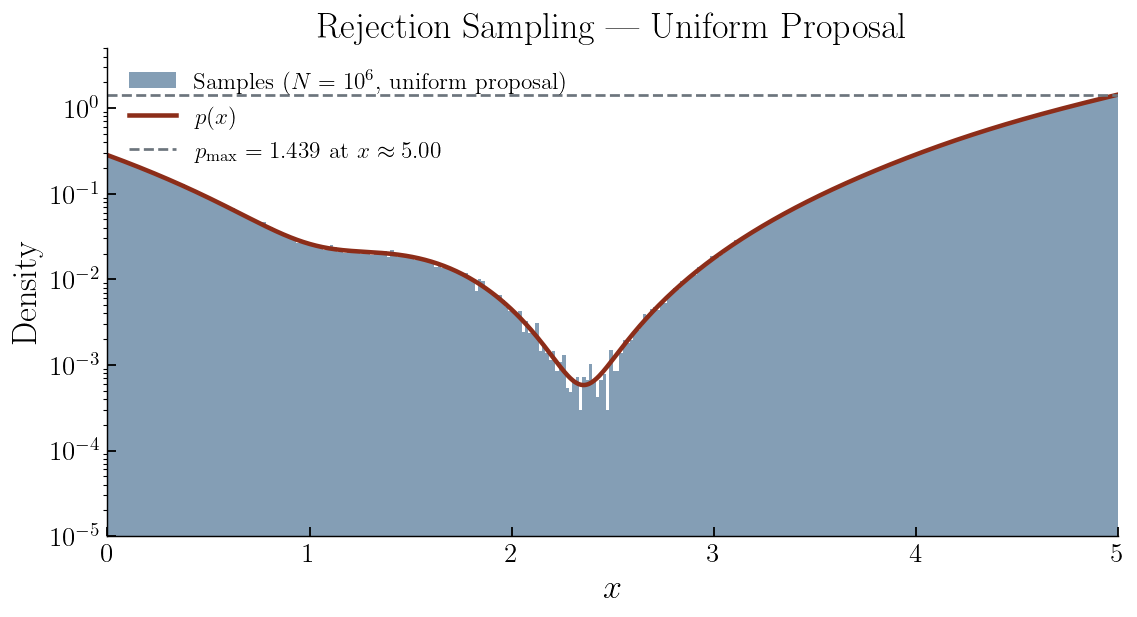

In [3]:
# 6.3 a,b: compute p0 and uniform-proposal rejection sampling

I1, _ = integrate.quad(lambda x: (x - 2)**4, 0, 5)
I2, _ = integrate.quad(lambda x: np.sin(x - 3)**8, 0, 5)
p0 = 1.0 / (I1 + I2)
print(f'I1 = {I1:.6f}  (analytic 55)')
print(f'I2 = {I2:.6f}')
print(f'p0 = {p0:.8f}')

def p63(x):
    return p0 * ((x - 2)**4 + np.sin(x - 3)**8)

norm_check, _ = integrate.quad(p63, 0, 5)
print(f'Normalisation check: {norm_check:.10f}')

x_fine = np.linspace(0, 5, 50_000)
p_vals = p63(x_fine)
p_max  = p_vals.max()
x_pmax = x_fine[p_vals.argmax()]
print(f'\np_max = {p_max:.6f} at x = {x_pmax:.3f}')
print(f'Expected acceptance rate (uniform): {100.0 / (5.0 * p_max):.2f}%')

rng      = np.random.default_rng(0)
N_target = 1_000_000
N_batch  = int(N_target * 5.0 * p_max * 1.5)
X_prop   = rng.uniform(0.0, 5.0, N_batch)
Y_prop   = rng.uniform(0.0, p_max, N_batch)
accept_b = Y_prop <= p63(X_prop)
samples_b = X_prop[accept_b][:N_target]
rej_rate_b = 1.0 - accept_b.mean()
print(f'Observed rejection rate (uniform): {rej_rate_b * 100:.2f}%')

x_plot = np.linspace(0, 5, 800)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(samples_b, bins=300, density=True,
        color=C_BLUE, alpha=0.55, label=r'Samples ($N=10^6$, uniform proposal)')
ax.plot(x_plot, p63(x_plot), lw=2.5, color=C_ORANGE,
        label=r'$p(x)$')
ax.axhline(p_max, ls='--', lw=1.5, color=C_GRAY,
           label=rf'$p_{{\rm max}}={p_max:.3f}$ at $x\approx{x_pmax:.2f}$')
ax.set_xlabel(r'$x$')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.set_xlim(0, 5)
ax.set_ylim(1e-5, 5)
ax.set_title('Rejection Sampling — Uniform Proposal')
ax.legend(fontsize=fontsi - 2, loc='upper left')
ax.tick_params(direction='in', length=5, width=1.0)
plt.tight_layout()
plt.savefig('sheet6_output/rejection_uniform.pdf', bbox_inches='tight')
plt.show()

Envelope area A_tot = 1.4650
Theoretical acceptance rate = 68.26%
Max [p(x) - q(x)] = -0.005561  (must be <= 0)
Observed rejection rate (envelope): 31.72%
Improvement vs uniform: 2.71x lower rejection rate


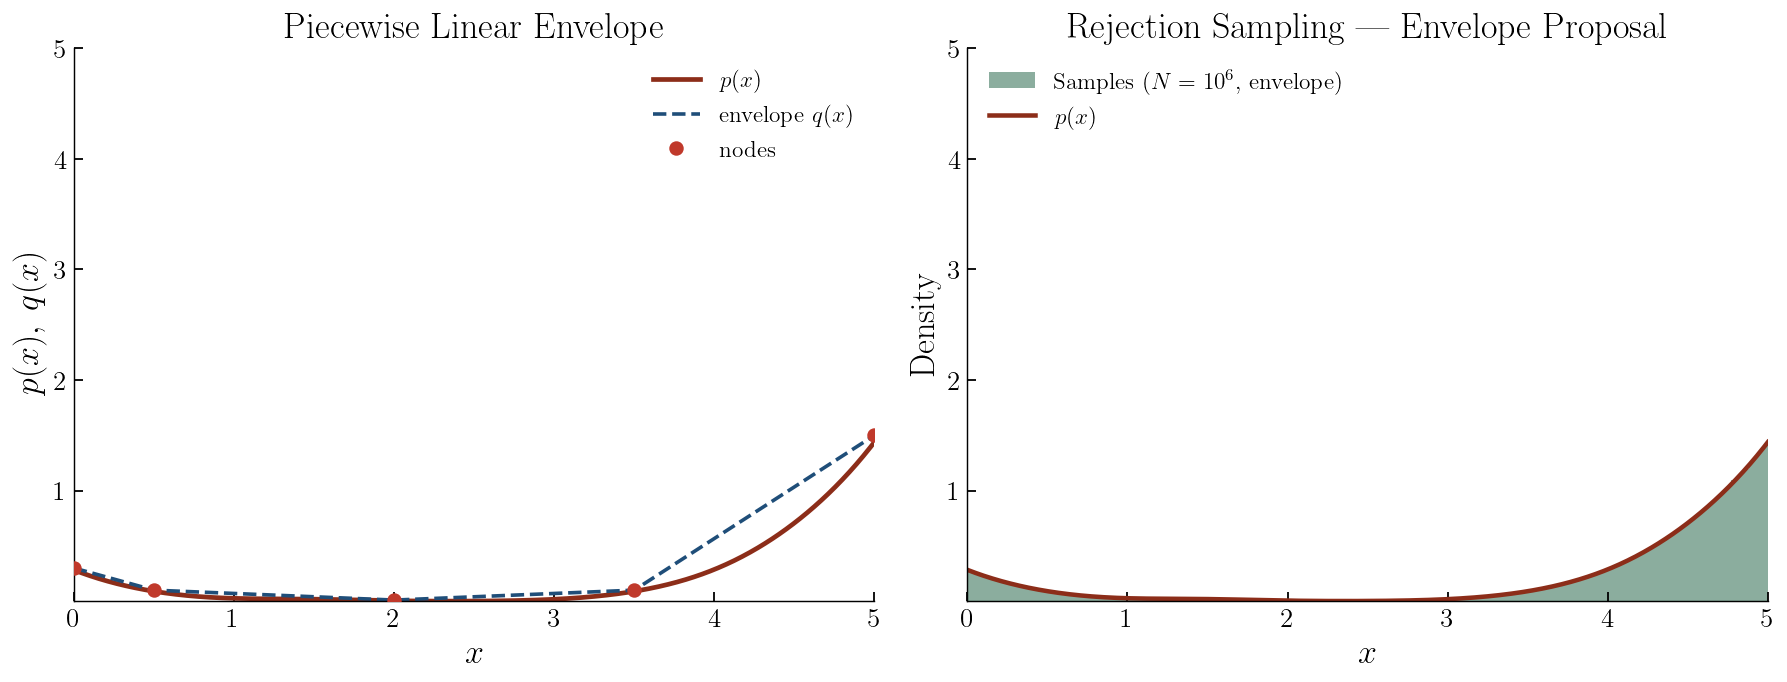

In [4]:
# 6.3 c: piecewise-linear envelope rejection sampling

xn = np.array([0.0,  0.50, 2.00, 3.50, 5.0 ])
yn = np.array([0.30, 0.10, 0.01, 0.10, 1.50])
n_seg  = len(xn) - 1
widths = np.diff(xn)
areas  = 0.5 * (yn[:-1] + yn[1:]) * widths   # trapezoid areas
A_tot  = areas.sum()
seg_probs = areas / A_tot
print(f'Envelope area A_tot = {A_tot:.4f}')
print(f'Theoretical acceptance rate = {100.0 / A_tot:.2f}%')

def q_eval(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    for k in range(n_seg):
        mask = (x >= xn[k]) & (x <= xn[k + 1])
        t = (x[mask] - xn[k]) / widths[k]
        out[mask] = (1 - t) * yn[k] + t * yn[k + 1]
    return out

# Verify q(x) >= p(x) everywhere
x_check   = np.linspace(0, 5, 2_000_000)
violation = (p63(x_check) - q_eval(x_check)).max()
print(f'Max [p(x) - q(x)] = {violation:.6f}  (must be <= 0)')

# Sample from q: choose segment proportionally to area,
# then invert the linear CDF within the segment.
def sample_from_q(n, rng_):
    seg_idx = rng_.choice(n_seg, size=n, p=seg_probs)
    u_seg   = rng_.uniform(0.0, 1.0, n)
    samples = np.empty(n)
    for k in range(n_seg):
        mask = seg_idx == k
        if not mask.any():
            continue
        a  = yn[k]
        b  = (yn[k + 1] - yn[k]) / widths[k]
        uk = u_seg[mask]
        if abs(b) < 1e-14:          # constant segment
            t = uk * widths[k]
        else:
            # invert F_k(t) = (a*t + b*t^2/2) / area_k = u
            disc = a**2 + 2.0 * b * uk * areas[k]
            t    = (-a + np.sqrt(np.maximum(disc, 0.0))) / b
        samples[mask] = xn[k] + t
    return samples

rng2     = np.random.default_rng(1)
N_prop_c = int(N_target * A_tot * 1.5)
X_q      = sample_from_q(N_prop_c, rng2)
u_acc    = rng2.uniform(0.0, 1.0, N_prop_c)
ratio    = np.clip(p63(X_q) / q_eval(X_q), 0.0, 1.0)
accept_c = u_acc <= ratio
samples_c = X_q[accept_c][:N_target]
rej_rate_c = 1.0 - accept_c.mean()
print(f'Observed rejection rate (envelope): {rej_rate_c * 100:.2f}%')
print(f'Improvement vs uniform: {rej_rate_b / rej_rate_c:.2f}x lower rejection rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.plot(x_plot, p63(x_plot), lw=2.6,
            color=C_ORANGE, label=r'$p(x)$')
ax.plot(x_plot, q_eval(x_plot), lw=2.0, color=C_BLUE, ls='--',
            label=r'envelope $q(x)$')
ax.plot(xn, yn, 'o', color=C_RED, ms=7, zorder=5, label='nodes')
ax.set_xlim(0, 5)
ax.set_ylim(1e-3, 5)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$p(x),\;q(x)$')
ax.set_title('Piecewise Linear Envelope')
ax.legend(fontsize=fontsi - 2)
ax.tick_params(direction='in', length=5, width=1.0)

ax2 = axes[1]
ax2.hist(samples_c, bins=300, density=True,
         color=C_GREEN, alpha=0.55, label=r'Samples ($N=10^6$, envelope)')
ax2.plot(x_plot, p63(x_plot), lw=2.5,
         color=C_ORANGE, label=r'$p(x)$')
ax2.set_xlabel(r'$x$')
ax2.set_ylabel('Density')
#ax2.set_yscale('log')
ax2.set_xlim(0, 5)
ax2.set_ylim(1e-5, 5)
ax2.set_title('Rejection Sampling — Envelope Proposal')
ax2.legend(fontsize=fontsi - 2, loc='upper left')
ax2.tick_params(direction='in', length=5, width=1.0)

plt.tight_layout()
plt.savefig('sheet6_output/rejection_envelope.pdf', bbox_inches='tight')
plt.show()